# House Price Prediction — Part 2: Model Training & Comparison
**Goal:** Train multiple regression models, compare them, select the best one, and save the pipeline.

## 0. Import Libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Create models directory
os.makedirs('models', exist_ok=True)

## 1. Load Data & Feature Selection

In [74]:
df = pd.read_csv('USA_Housing.csv')

FEATURES = [
    'Avg. Area Income',
    'Avg. Area House Age',
    'Avg. Area Number of Rooms',
    'Avg. Area Number of Bedrooms',
    'Area Population'
]
TARGET = 'Price'

X = df[FEATURES]
y = df[TARGET]

print(f'Features : {FEATURES}')
print(f'Target   : {TARGET}')
print(f'X shape  : {X.shape}')
print(f'y shape  : {y.shape}')

Features : ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']
Target   : Price
X shape  : (5000, 5)
y shape  : (5000,)


## 2. Train / Test Split (80/20)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Test samples     : {X_test.shape[0]:,}')

Training samples : 4,000
Test samples     : 1,000


## 3. Train Multiple Models

In [76]:
#function to evaluate any pipeline
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)

    y_train_pred = pipeline.predict(X_tr)
    y_test_pred  = pipeline.predict(X_te)

    train_r2  = r2_score(y_tr, y_train_pred)
    test_r2   = r2_score(y_te, y_test_pred)
    test_mse  = mean_squared_error(y_te, y_test_pred)
    test_rmse = np.sqrt(test_mse)

    print(f'  {name}')
    print(f'    Train R²: {train_r2:.4f}  |  Test R²: {test_r2:.4f}  |  Test RMSE: ${test_rmse:,.0f}')

    return {
        'Model': name,
        'Train R²': round(train_r2, 4),
        'Test R²':  round(test_r2,  4),
        'Test MSE': round(test_mse, 0),
        'pipeline': pipeline
    }

results = []
print('Training models...')

Training models...


In [77]:
# Model 1: Linear Regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
results.append(evaluate_model('Linear Regression', pipe_lr, X_train, y_train, X_test, y_test))

  Linear Regression
    Train R²: 0.9180  |  Test R²: 0.9180  |  Test RMSE: $100,444


In [78]:
# Model 2: Ridge Regression
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10))
])
results.append(evaluate_model('Ridge Regression (alpha=10)', pipe_ridge, X_train, y_train, X_test, y_test))

  Ridge Regression (alpha=10)
    Train R²: 0.9180  |  Test R²: 0.9180  |  Test RMSE: $100,447


In [79]:
# Model 3: Lasso Regression
pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=100))
])
results.append(evaluate_model('Lasso Regression (alpha=100)', pipe_lasso, X_train, y_train, X_test, y_test))

  Lasso Regression (alpha=100)
    Train R²: 0.9180  |  Test R²: 0.9180  |  Test RMSE: $100,442


In [80]:
# Model 4: Polynomial Regression (degree=2) + Ridge
pipe_poly = Pipeline([
    ('scaler',  StandardScaler()),
    ('poly',    PolynomialFeatures(degree=2, include_bias=True)),
    ('model',   Ridge(alpha=10))
])
results.append(evaluate_model('Polynomial (deg=2) + Ridge', pipe_poly, X_train, y_train, X_test, y_test))

  Polynomial (deg=2) + Ridge
    Train R²: 0.9181  |  Test R²: 0.9179  |  Test RMSE: $100,496


In [81]:
# Model 5: KNN Regression

# KNN k=1
pipe_knn1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=1))
])
results.append(evaluate_model('KNN (k=1)', pipe_knn1, X_train, y_train, X_test, y_test))

# KNN k=3
pipe_knn3 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=3))
])
results.append(evaluate_model('KNN (k=3)', pipe_knn3, X_train, y_train, X_test, y_test))


# KNN k=5
pipe_knn5 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=5))
])
results.append(evaluate_model('KNN (k=5)', pipe_knn5, X_train, y_train, X_test, y_test))

# KNN k=10
pipe_knn10 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=10))
])
results.append(evaluate_model('KNN (k=10)', pipe_knn10, X_train, y_train, X_test, y_test))

  KNN (k=1)
    Train R²: 1.0000  |  Test R²: 0.7767  |  Test RMSE: $165,746
  KNN (k=3)
    Train R²: 0.9280  |  Test R²: 0.8507  |  Test RMSE: $135,535
  KNN (k=5)
    Train R²: 0.9109  |  Test R²: 0.8693  |  Test RMSE: $126,800
  KNN (k=10)
    Train R²: 0.8987  |  Test R²: 0.8753  |  Test RMSE: $123,866


## 4. Model Comparison Table

In [82]:
comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'pipeline'}
    for r in results
])
comparison_df = comparison_df.sort_values('Test R²', ascending=False).reset_index(drop=True)

print('MODEL COMPARISON TABLE (sorted by Test R²)')
print(comparison_df.to_string(index=False))

MODEL COMPARISON TABLE (sorted by Test R²)
                       Model  Train R²  Test R²     Test MSE
           Linear Regression    0.9180   0.9180 1.008901e+10
 Ridge Regression (alpha=10)    0.9180   0.9180 1.008965e+10
Lasso Regression (alpha=100)    0.9180   0.9180 1.008859e+10
  Polynomial (deg=2) + Ridge    0.9181   0.9179 1.009954e+10
                  KNN (k=10)    0.8987   0.8753 1.534290e+10
                   KNN (k=5)    0.9109   0.8693 1.607824e+10
                   KNN (k=3)    0.9280   0.8507 1.836970e+10
                   KNN (k=1)    1.0000   0.7767 2.747168e+10


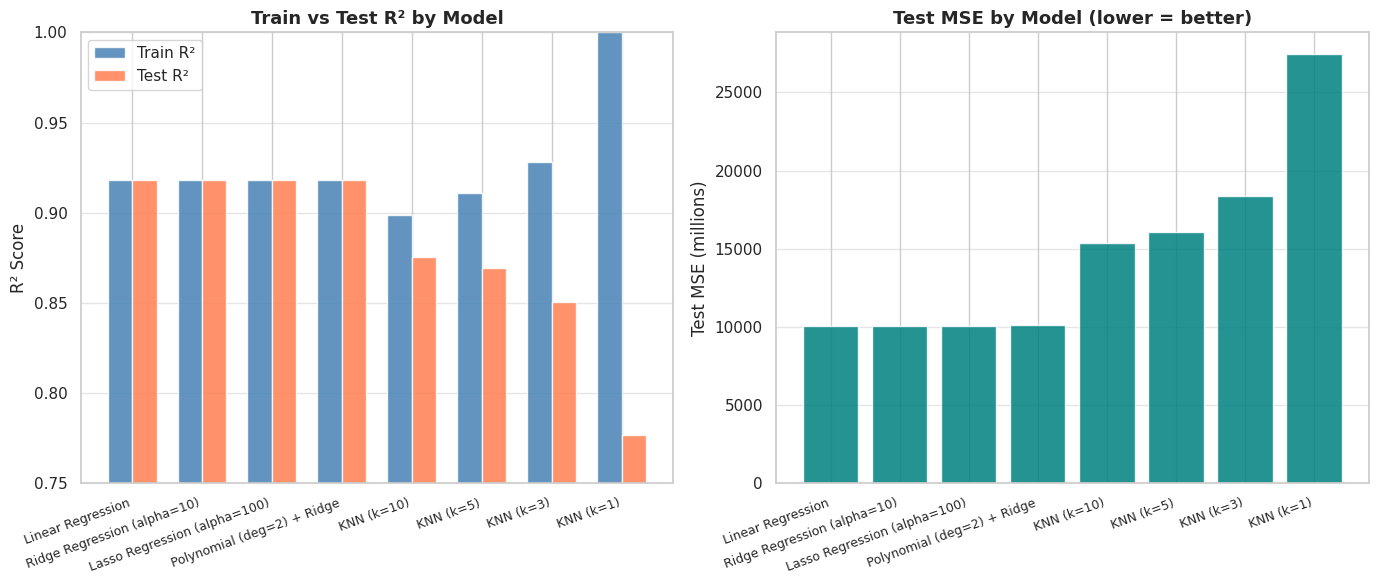

In [83]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_names = comparison_df['Model']
x = np.arange(len(model_names))
w = 0.35

# R² comparison
axes[0].bar(x - w/2, comparison_df['Train R²'], w, label='Train R²', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, comparison_df['Test R²'],  w, label='Test R²',  color='coral',     alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0.75, 1.0)
axes[0].set_title('Train vs Test R² by Model', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.5)

# MSE comparison
axes[1].bar(x, comparison_df['Test MSE'] / 1e6, color='teal', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Test MSE (millions)')
axes[1].set_title('Test MSE by Model (lower = better)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Select Best Model

In [84]:
# Automatically pick model with highest Test R²
best_idx  = comparison_df['Test R²'].idxmax()
best_row  = comparison_df.loc[best_idx]
best_name = best_row['Model']

# Retrieve matching pipeline from results list
best_pipeline = next(r['pipeline'] for r in results if r['Model'] == best_name)

print('BEST MODEL SELECTED')
print(f'  Name     : {best_name}')
print(f'  Train R² : {best_row["Train R²"]:.4f}')
print(f'  Test R²  : {best_row["Test R²"]:.4f}')
print(f'  Test MSE : ${best_row["Test MSE"]:,.0f}')
print()

train_r2 = best_row['Train R²']
test_r2  = best_row['Test R²']
diff = train_r2 - test_r2
if diff < 0.02:
    print('Overfitting check PASSED — Train R² ≈ Test R² (no significant overfitting)')
elif diff < 0.05:
    print('Minor gap between Train and Test R² — slight overfitting')
else:
    print('Significant overfitting detected — consider more regularization')

BEST MODEL SELECTED
  Name     : Linear Regression
  Train R² : 0.9180
  Test R²  : 0.9180
  Test MSE : $10,089,009,301

Overfitting check PASSED — Train R² ≈ Test R² (no significant overfitting)


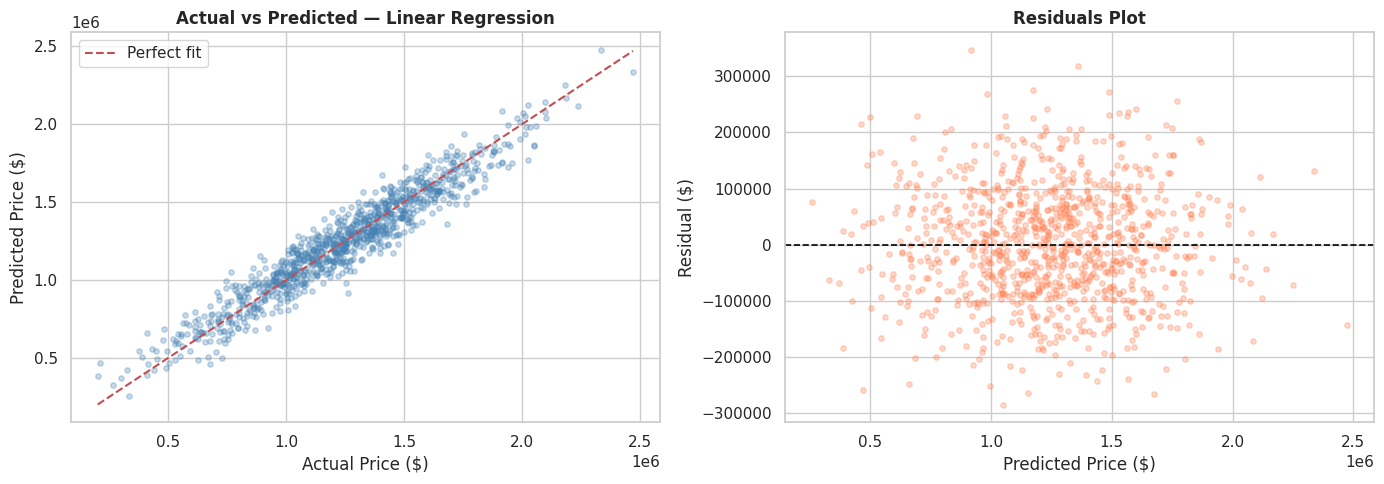

In [85]:
# Actual vs Predicted plot for best model
y_pred = best_pipeline.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Actual vs Predicted — {best_name}', fontsize=12, fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, s=15, color='coral')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residuals Plot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('best_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Pipeline

In [86]:
model_path = 'models/best_model.pkl'
joblib.dump(best_pipeline, model_path)

# Save feature list too (needed by Gradio app)
joblib.dump(FEATURES, 'models/features.pkl')

print(f'Pipeline saved to: {model_path}')

# Verify by reloading
loaded = joblib.load(model_path)
test_pred = loaded.predict(X_test[:5])
print(f'\nVerification — 5 sample predictions:')
for actual, pred in zip(y_test[:5].values, test_pred):
    print(f'  Actual: ${actual:>12,.0f}   Predicted: ${pred:>12,.0f}')
print('\n✅ Model saved and verified successfully!')

Pipeline saved to: models/best_model.pkl

Verification — 5 sample predictions:
  Actual: $   1,339,096   Predicted: $   1,308,588
  Actual: $   1,251,794   Predicted: $   1,237,037
  Actual: $   1,340,095   Predicted: $   1,243,429
  Actual: $   1,431,508   Predicted: $   1,228,900
  Actual: $   1,042,374   Predicted: $   1,063,321

✅ Model saved and verified successfully!
